# Lab 3: Working with Embedding Models, FAISS, and Vector Databases
## Generative AI Masterclass

This lab will guide you through:
1. Understanding embeddings and their importance in GenAI
2. Using Hugging Face embedding models
3. Setting up a FAISS vector database
4. Ingesting data into a vector database
5. Performing approximate nearest neighbor (ANN) search
6. Building a simple retrieval system

## Installation and Setup

### Prerequisites
- Anaconda or Miniconda installed on your system
- Basic familiarity with terminal/command line
- Basic Python knowledge

Let's create and activate a clean Python environment to avoid package conflicts:

```bash
# Create new conda environment
conda create --name lab_3 python=3.9

# Activate the environment
conda activate lab_3

# Install Jupyter support
conda install ipykernel
```

Let's start by installing the necessary libraries:

In [3]:
# Install required libraries
!pip install --quiet sentence-transformers faiss-cpu matplotlib pandas numpy scikit-learn tqdm seaborn

In [4]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from tqdm.notebook import tqdm
import torch
from sentence_transformers import SentenceTransformer
import faiss
import time

/home/studio-lab-user/.conda/envs/lab_2/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Introduction to Embeddings

### What are embeddings?

Embeddings are dense vector representations of data (text, images, etc.) in a continuous vector space. They capture semantic meaning and relationships between items.

In NLP, word or sentence embeddings map text to vectors where similar meanings are positioned closer in vector space. This allows us to:
- Measure semantic similarity between texts
- Find related content
- Perform vector operations that mirror semantic relationships

Let's visualize some word embeddings to understand their structure and relationships.

In [5]:
# Example words to visualize
example_words = [
    "king", "queen", "man", "woman", "doctor", "nurse", 
    "computer", "laptop", "code", "program",
    "happy", "sad", "angry", "joyful"
]

# Load a simple model to create embeddings
model = SentenceTransformer('all-MiniLM-L6-v2')
word_embeddings = model.encode(example_words)

print(f"Shape of embeddings: {word_embeddings.shape}")
print(f"This means we have {word_embeddings.shape[0]} words, each represented by {word_embeddings.shape[1]} dimensions")

Shape of embeddings: (14, 384)
This means we have 14 words, each represented by 384 dimensions


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


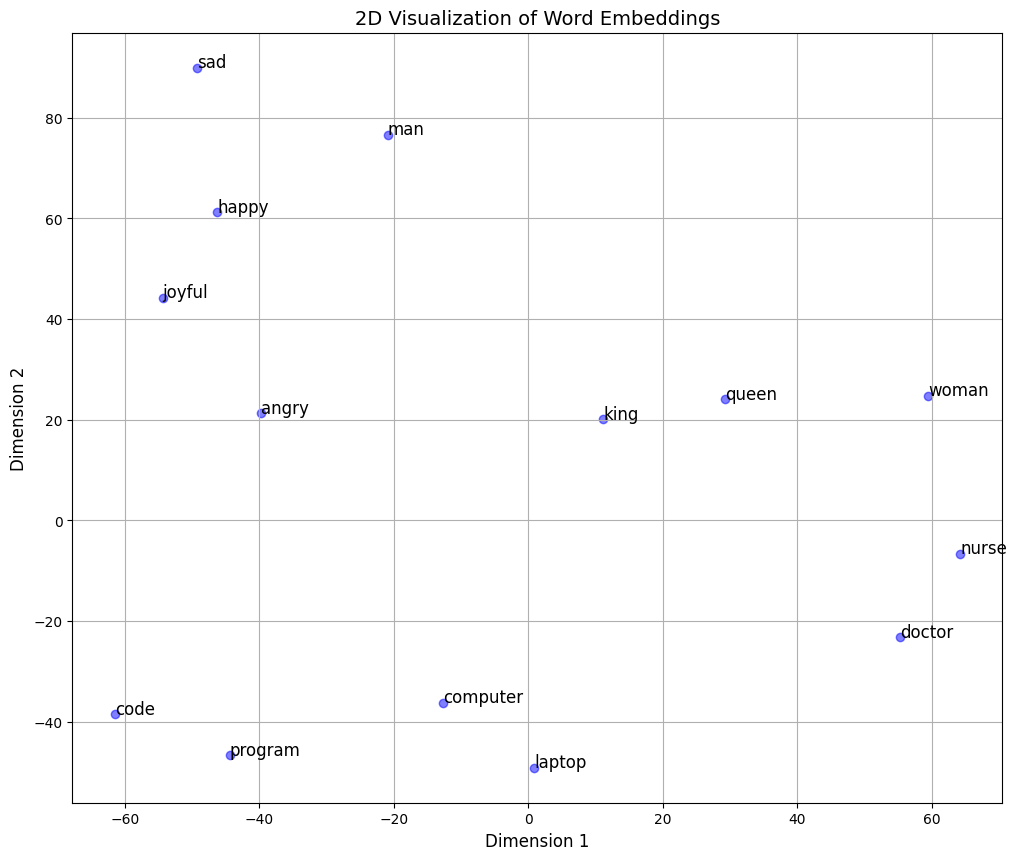

In [7]:
# Reduce dimensions for visualization using t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
embeddings_2d = tsne.fit_transform(word_embeddings)

# Plot the 2D embeddings
plt.figure(figsize=(12, 10))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c='blue', alpha=0.5)

for i, word in enumerate(example_words):
    plt.annotate(word, (embeddings_2d[i, 0], embeddings_2d[i, 1]), fontsize=12)

plt.title("2D Visualization of Word Embeddings", fontsize=14)
plt.xlabel("Dimension 1", fontsize=12)
plt.ylabel("Dimension 2", fontsize=12)
plt.grid(True)
plt.show()

**Note**: In the visualization above, notice how semantically related words cluster together:
- Gender pairs (king/queen, man/woman) should be close to each other
- Technology terms (computer, laptop, code, program) form a cluster
- Emotions (happy, sad, angry, joyful) group together

Now, let's explore vector operations and the famous word analogy task.

In [8]:
# Function to find the closest word to a given vector
def find_closest_word(vector, word_list, embeddings, exclude=None):
    if exclude is None:
        exclude = set()
    
    # Calculate cosine similarity
    from sklearn.metrics.pairwise import cosine_similarity
    similarities = cosine_similarity([vector], embeddings)[0]
    
    # Sort by similarity
    sorted_indices = np.argsort(-similarities)
    
    # Find the most similar word that's not in the exclude list
    for idx in sorted_indices:
        if word_list[idx] not in exclude:
            return word_list[idx], similarities[idx]
    
    return None, 0

# Example: king - man + woman = ?
king_idx = example_words.index("king")
man_idx = example_words.index("man")
woman_idx = example_words.index("woman")

result_vector = word_embeddings[king_idx] - word_embeddings[man_idx] + word_embeddings[woman_idx]
closest_word, similarity = find_closest_word(result_vector, example_words, word_embeddings, 
                                            exclude={"king", "man", "woman"})

print(f"king - man + woman = {closest_word} (similarity: {similarity:.4f})")

king - man + woman = queen (similarity: 0.5795)


## 2. Working with Hugging Face Embedding Models

Hugging Face provides access to various embedding models:
1. Sentence Transformers - optimized for creating sentence embeddings
2. BERT and its variants - can be used for token or sentence-level embeddings
3. Domain-specific models - tailored for specific applications

Let's explore how to work with these models to generate embeddings for sentences.

In [9]:
# Load a sentence transformer model
model_name = 'all-MiniLM-L6-v2'  # A lightweight but effective model
model = SentenceTransformer(model_name)

print(f"Model: {model_name}")
print(f"Embedding dimension: {model.get_sentence_embedding_dimension()}")

# Example sentences to embed
sentences = [
    "The cat sat on the mat.",
    "The feline rested on the rug.",  # Semantically similar to the first sentence
    "Dogs are loyal pets.",  # Different topic
    "AI is transforming the world.",  # Completely different domain
    "Machine learning models require data."  # Related to AI but not to cats
]

# Create embeddings
embeddings = model.encode(sentences)

print(f"Shape of embeddings: {embeddings.shape}")
print(f"Sample embedding (first 5 dimensions): {embeddings[0][:5]}")

Model: all-MiniLM-L6-v2
Embedding dimension: 384
Shape of embeddings: (5, 384)
Sample embedding (first 5 dimensions): [ 0.13023724 -0.01577283 -0.03671667  0.0579864  -0.05979175]


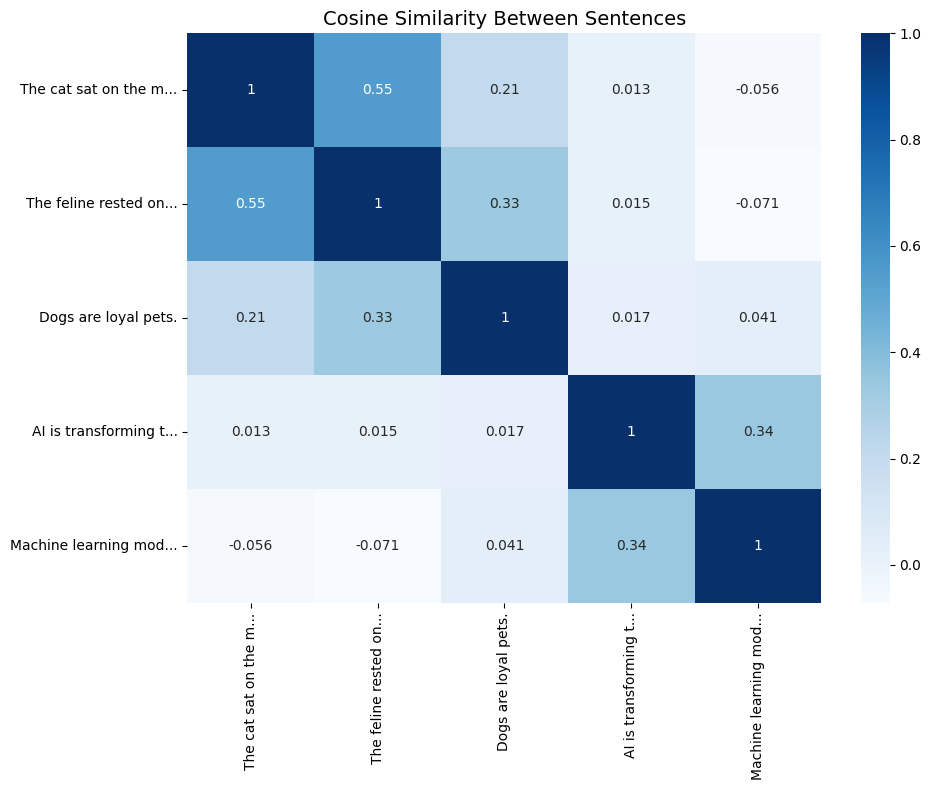

In [10]:
# Compute similarity between sentence pairs
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(embeddings)

# Create a heatmap to visualize similarity
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, annot=True, cmap='Blues', 
            xticklabels=[s[:20] + '...' if len(s) > 20 else s for s in sentences], 
            yticklabels=[s[:20] + '...' if len(s) > 20 else s for s in sentences])
plt.title("Cosine Similarity Between Sentences", fontsize=14)
plt.tight_layout()
plt.show()

**Observations**: 
- The first two sentences (about cats) should have high similarity
- The last two sentences (about AI) should have high similarity
- Sentences from different domains should have lower similarity

## 3. Vector Databases and FAISS

Vector databases store and efficiently search vector embeddings. FAISS (Facebook AI Similarity Search) is a library for efficient similarity search, especially in high-dimensional spaces.

Key features of FAISS:
- Highly optimized for similarity search in high-dimensional spaces
- Supports approximate nearest neighbor (ANN) search
- Various indexing methods for different use cases
- GPU acceleration support

Let's set up a simple FAISS index for our sentence embeddings.

In [11]:
# Setting up a simple FAISS index
dimension = model.get_sentence_embedding_dimension()  # Get embedding dimension from our model

# Create a simple flat index (exact search with L2 distance)
index = faiss.IndexFlatL2(dimension)

# Convert our embeddings to float32 as required by FAISS
embeddings_np = np.array(embeddings).astype('float32')

# Add vectors to the index
index.add(embeddings_np)

print(f"Index contains {index.ntotal} vectors of dimension {dimension}")

Index contains 5 vectors of dimension 384


Now let's perform a simple search to find the most similar sentences to a query.

In [12]:
# Create a new query
query = "A kitten is sitting on a carpet."
print(f"Query: '{query}'")

# Convert query to embedding
query_embedding = model.encode([query])[0].reshape(1, -1).astype('float32')

# Search for the 3 closest sentences
k = 3
distances, indices = index.search(query_embedding, k)

print(f"\nTop {k} most similar sentences:")
for i, idx in enumerate(indices[0]):
    print(f"{i+1}. '{sentences[idx]}' (Distance: {distances[0][i]:.4f})")

Query: 'A kitten is sitting on a carpet.'

Top 3 most similar sentences:
1. 'The cat sat on the mat.' (Distance: 0.7383)
2. 'The feline rested on the rug.' (Distance: 0.8694)
3. 'Dogs are loyal pets.' (Distance: 1.6557)


## 4. Ingesting Data into a Vector Database

Now, let's work with a larger dataset to demonstrate how to ingest data into a vector database. We'll create a dataset of movie descriptions.

In [13]:
# Sample movie descriptions
movie_data = [
    "A group of intergalactic criminals must pull together to stop a fanatical warrior with plans to purge the universe.",
    "The aging patriarch of an organized crime dynasty transfers control of his clandestine empire to his reluctant son.",
    "A meek Hobbit from the Shire and eight companions set out on a journey to destroy the powerful One Ring and save Middle-earth from the Dark Lord Sauron.",
    "A computer hacker learns from mysterious rebels about the true nature of his reality and his role in the war against its controllers.",
    "Two imprisoned men bond over a number of years, finding solace and eventual redemption through acts of common decency.",
    "A thief who steals corporate secrets through the use of dream-sharing technology is given the inverse task of planting an idea into the mind of a C.E.O.",
    "Luke Skywalker joins forces with a Jedi Knight, a cocky pilot, a Wookiee and two droids to save the galaxy from the Empire's world-destroying battle station.",
    "The lives of two mob hitmen, a boxer, a gangster and his wife, and a pair of diner bandits intertwine in four tales of violence and redemption.",
    "When the menace known as the Joker wreaks havoc and chaos on the people of Gotham, Batman must accept one of the greatest psychological and physical tests of his ability to fight injustice.",
    "A bounty hunting scam joins two men in an uneasy alliance against a third in a race to find a fortune in gold buried in a remote cemetery.",
    "An insomniac office worker and a devil-may-care soapmaker form an underground fight club that evolves into something much, much more.",
    "In Nazi-occupied France during World War II, a plan to assassinate Nazi leaders by a group of Jewish U.S. soldiers coincides with a theatre owner's vengeful plans for the same.",
    "A young F.B.I. cadet must receive the help of an incarcerated and manipulative cannibal killer to help catch another serial killer, a madman who skins his victims.",
    "With the help of a German bounty hunter, a freed slave sets out to rescue his wife from a brutal Mississippi plantation owner.",
    "A promising young drummer enrolls at a cut-throat music conservatory where his dreams of greatness are mentored by an instructor who will stop at nothing to realize a student's potential.",
    "The presidencies of Kennedy and Johnson, the events of Vietnam, Watergate, and other history unfold through the perspective of an Alabama man with an IQ of 75.",
    "After the devastating events of Avengers: Infinity War, the universe is in ruins. With the help of remaining allies, the Avengers assemble once more in order to reverse Thanos' actions and restore balance to the universe.",
    "A frontiersman on a fur trading expedition in the 1820s fights for survival after being mauled by a bear and left for dead by members of his own hunting team.",
    "An undercover cop and a mole in the police attempt to identify each other while infiltrating an Irish gang in South Boston.",
    "In the falangist Spain of 1944, the bookish young stepdaughter of a sadistic army officer escapes into an eerie but captivating fantasy world."
]

# Create movie titles for our dataset
movie_titles = [
    "Guardians of the Galaxy", "The Godfather", "The Lord of the Rings", "The Matrix", "The Shawshank Redemption",
    "Inception", "Star Wars", "Pulp Fiction", "The Dark Knight", "The Good, the Bad and the Ugly",
    "Fight Club", "Inglourious Basterds", "The Silence of the Lambs", "Django Unchained", "Whiplash",
    "Forrest Gump", "Avengers: Endgame", "The Revenant", "The Departed", "Pan's Labyrinth"
]

# Create a DataFrame to store our movie data
movie_df = pd.DataFrame({
    'title': movie_titles,
    'description': movie_data
})

print(f"Dataset contains {len(movie_df)} movies")
movie_df.head()

Dataset contains 20 movies


,title,description
0,Guardians of the Galaxy,A group of intergalactic criminals must pull t...
1,The Godfather,The aging patriarch of an organized crime dyna...
2,The Lord of the Rings,A meek Hobbit from the Shire and eight compani...
3,The Matrix,A computer hacker learns from mysterious rebel...
4,The Shawshank Redemption,Two imprisoned men bond over a number of years...


In [14]:
# Convert movie descriptions to embeddings
print("Creating embeddings for movie descriptions...")
movie_embeddings = model.encode(movie_df['description'].tolist(), show_progress_bar=True)

# Convert to correct format for FAISS
movie_embeddings = np.array(movie_embeddings).astype('float32')

# Create a new FAISS index for our movie dataset
movie_index = faiss.IndexFlatL2(dimension)
movie_index.add(movie_embeddings)

print(f"Movie index contains {movie_index.ntotal} vectors")

Creating embeddings for movie descriptions...


Batches: 100%|██████████| 1/1 [00:00<00:00,  4.44it/s]

Movie index contains 20 vectors


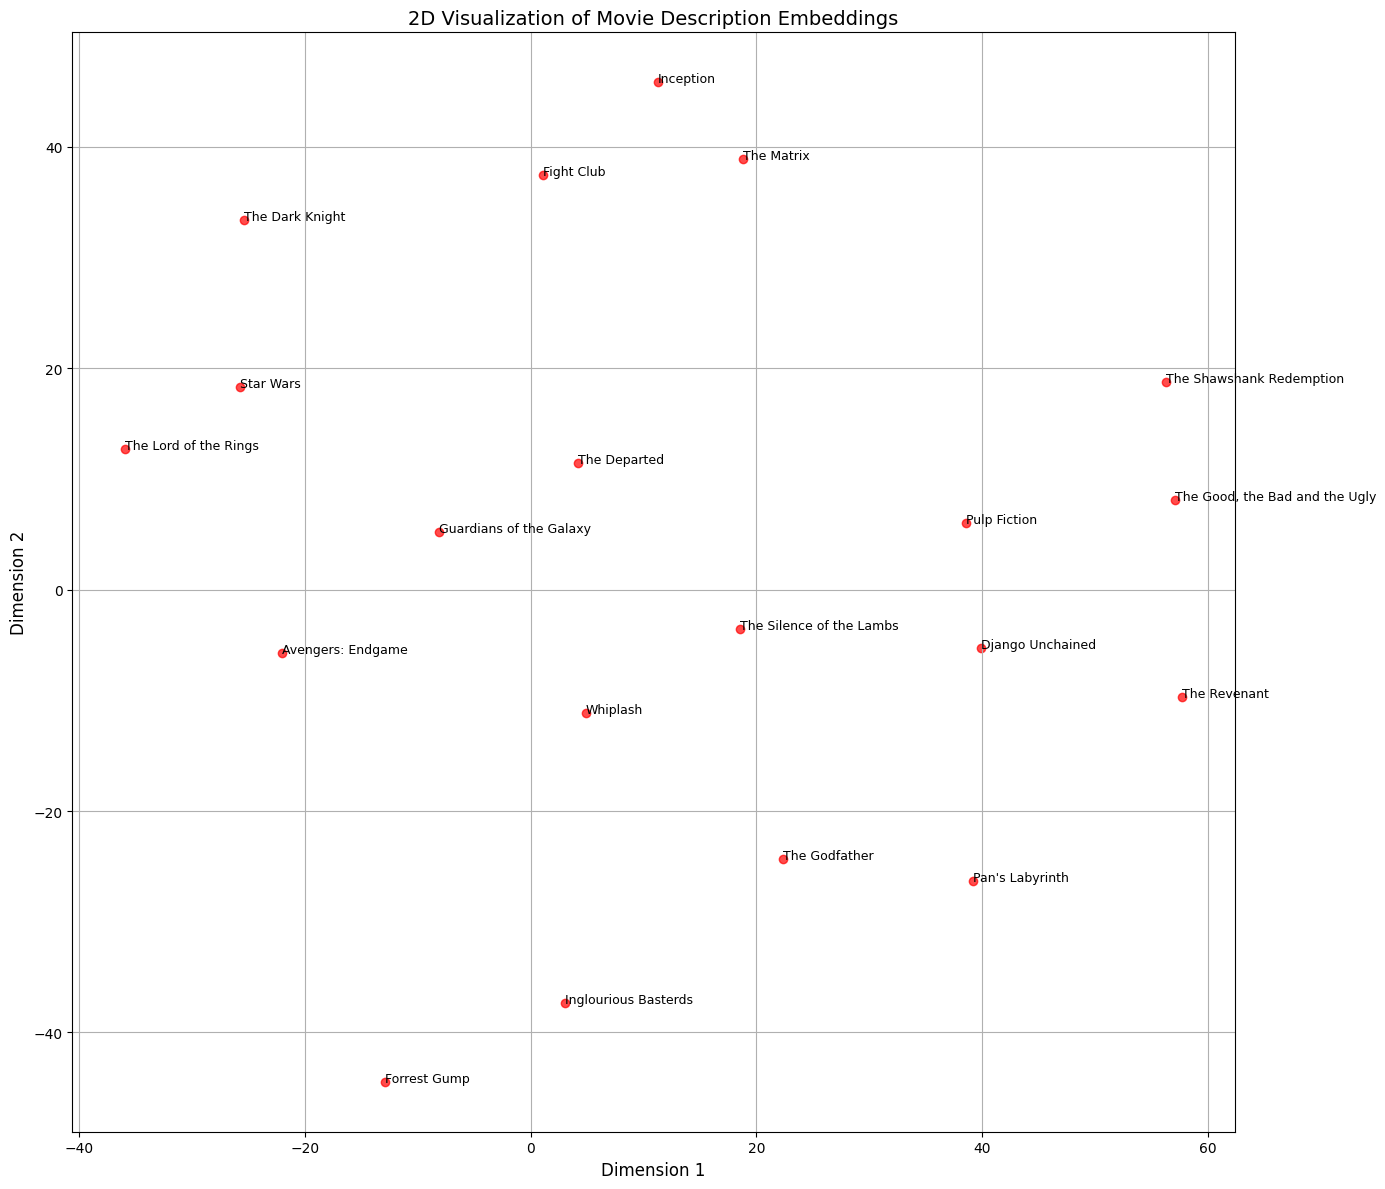

In [16]:
# Visualization: Let's visualize the movie embeddings in 2D
# Reduce dimensions using t-SNE
movie_embeddings_2d = TSNE(n_components=2, random_state=42, perplexity=5).fit_transform(movie_embeddings)

# Plot
plt.figure(figsize=(14, 12))
plt.scatter(movie_embeddings_2d[:, 0], movie_embeddings_2d[:, 1], c='red', alpha=0.7)

for i, title in enumerate(movie_titles):
    plt.annotate(title, (movie_embeddings_2d[i, 0], movie_embeddings_2d[i, 1]), fontsize=9)

plt.title("2D Visualization of Movie Description Embeddings", fontsize=14)
plt.xlabel("Dimension 1", fontsize=12)
plt.ylabel("Dimension 2", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

**Observations**: Look for clustering patterns in the visualization. You should notice:
- Sci-fi movies (The Matrix, Star Wars, Avengers) tend to cluster together
- Crime/mafia movies (The Godfather, Pulp Fiction) form another cluster
- Fantasy movies might form their own cluster

## 5. Approximate Nearest Neighbor (ANN) Search

Exact search (like with IndexFlatL2) works well for smaller datasets but becomes slow for millions of vectors. Approximate Nearest Neighbor (ANN) search sacrifices some accuracy for greatly improved speed.

FAISS provides several ANN index types:
- IndexIVFFlat: divides the space into cells and only searches relevant cells
- IndexHNSW: uses hierarchical navigable small world graphs
- IndexPQ: uses product quantization to compress vectors

First, let's define a search function for our movie database:

In [17]:
def search_movies(query_text, k=5):
    """
    Search for movies similar to the query text
    """
    # Create embedding for the query
    query_embedding = model.encode([query_text])[0].reshape(1, -1).astype('float32')
    
    # Search the index
    distances, indices = movie_index.search(query_embedding, k)
    
    # Return results
    results = []
    for i, idx in enumerate(indices[0]):
        results.append({
            'title': movie_df.iloc[idx]['title'],
            'description': movie_df.iloc[idx]['description'],
            'distance': distances[0][i]
        })
    
    return results

# Try a few searches
queries = [
    "space adventure with aliens",
    "crime boss and family drama",
    "dream manipulation and heist",
    "war and violence",
    "artificial intelligence and virtual reality"
]

for query in queries:
    print(f"\nQuery: '{query}'")
    results = search_movies(query)
    print("Top results:")
    for i, res in enumerate(results):
        print(f"{i+1}. {res['title']} (Distance: {res['distance']:.2f})")
        print(f"   {res['description'][:100]}...")


Query: 'space adventure with aliens'
Top results:
1. Guardians of the Galaxy (Distance: 1.53)
   A group of intergalactic criminals must pull together to stop a fanatical warrior with plans to purg...
2. The Lord of the Rings (Distance: 1.53)
   A meek Hobbit from the Shire and eight companions set out on a journey to destroy the powerful One R...
3. The Good, the Bad and the Ugly (Distance: 1.54)
   A bounty hunting scam joins two men in an uneasy alliance against a third in a race to find a fortun...
4. Pan's Labyrinth (Distance: 1.55)
   In the falangist Spain of 1944, the bookish young stepdaughter of a sadistic army officer escapes in...
5. The Departed (Distance: 1.61)
   An undercover cop and a mole in the police attempt to identify each other while infiltrating an Iris...

Query: 'crime boss and family drama'
Top results:
1. Pulp Fiction (Distance: 1.07)
   The lives of two mob hitmen, a boxer, a gangster and his wife, and a pair of diner bandits intertwin...
2. The Godfather 

Now, let's set up an ANN index for faster searching with larger datasets:

In [18]:
# Setting up an ANN index for faster searching
# We'll use IVF (Inverted File Index) with 4 clusters (normally would use more for larger datasets)
nlist = 4  # Number of clusters
quantizer = faiss.IndexFlatL2(dimension)  # The quantizer defines how to measure distances
ann_index = faiss.IndexIVFFlat(quantizer, dimension, nlist, faiss.METRIC_L2)

# Need to train the index with our data
ann_index.train(movie_embeddings)  
ann_index.add(movie_embeddings)

# Set the number of clusters to search (nprobe)
# Higher values = more accurate but slower search
ann_index.nprobe = 2

print(f"ANN index contains {ann_index.ntotal} vectors")

ANN index contains 20 vectors


WARNING clustering 20 points to 4 centroids: please provide at least 156 training points


In [19]:
def compare_search_performance(query_text, k=5):
    """
    Compare search performance between exact and approximate search
    """
    # Create embedding for the query
    query_embedding = model.encode([query_text])[0].reshape(1, -1).astype('float32')
    
    # Time exact search
    start_time = time.time()
    exact_distances, exact_indices = movie_index.search(query_embedding, k)
    exact_time = time.time() - start_time
    
    # Time approximate search
    start_time = time.time()
    ann_distances, ann_indices = ann_index.search(query_embedding, k)
    ann_time = time.time() - start_time
    
    # Print results
    print(f"Exact search took {exact_time:.6f} seconds")
    print(f"Approximate search took {ann_time:.6f} seconds")
    print(f"Speedup: {exact_time/ann_time:.2f}x")
    
    # Compare results
    print("\nExact search results:")
    for i, idx in enumerate(exact_indices[0]):
        if idx == -1:  # FAISS returns -1 if fewer than k results found
            continue
        print(f"{i+1}. {movie_df.iloc[idx]['title']} (Distance: {exact_distances[0][i]:.2f})")
    
    print("\nApproximate search results:")
    for i, idx in enumerate(ann_indices[0]):
        if idx == -1:  # FAISS returns -1 if fewer than k results found
            continue
        print(f"{i+1}. {movie_df.iloc[idx]['title']} (Distance: {ann_distances[0][i]:.2f})")

# Test on a few queries
test_queries = [
    "space adventure with aliens",
    "crime and revenge"
]

for query in test_queries:
    print(f"\n=== Query: '{query}' ===")
    compare_search_performance(query)


=== Query: 'space adventure with aliens' ===
Exact search took 0.000081 seconds
Approximate search took 0.000048 seconds
Speedup: 1.68x

Exact search results:
1. Guardians of the Galaxy (Distance: 1.53)
2. The Lord of the Rings (Distance: 1.53)
3. The Good, the Bad and the Ugly (Distance: 1.54)
4. Pan's Labyrinth (Distance: 1.55)
5. The Departed (Distance: 1.61)

Approximate search results:
1. Guardians of the Galaxy (Distance: 1.53)
2. The Lord of the Rings (Distance: 1.53)
3. The Good, the Bad and the Ugly (Distance: 1.54)
4. Pan's Labyrinth (Distance: 1.55)
5. The Departed (Distance: 1.61)

=== Query: 'crime and revenge' ===
Exact search took 0.000039 seconds
Approximate search took 0.000030 seconds
Speedup: 1.32x

Exact search results:
1. Pulp Fiction (Distance: 1.16)
2. The Shawshank Redemption (Distance: 1.27)
3. The Departed (Distance: 1.27)
4. Inception (Distance: 1.29)
5. Inglourious Basterds (Distance: 1.30)

Approximate search results:
1. Pulp Fiction (Distance: 1.16)
2. Th

**Note**: For this small dataset, you might not see significant performance improvements with ANN. The benefits become more pronounced with millions of vectors.

Let's compare the accuracy of exact vs. approximate search:

In [20]:
def measure_ann_accuracy(k=5, num_queries=10):
    """
    Measure how often ANN retrieves the same results as exact search
    """
    # Generate random query vectors
    import random
    query_indices = random.sample(range(len(movie_df)), num_queries)
    query_vectors = movie_embeddings[query_indices]
    
    total_overlap = 0
    
    for i, query in enumerate(query_vectors):
        query = query.reshape(1, -1)
        
        # Exact search
        _, exact_indices = movie_index.search(query, k+1)  # +1 because the query itself will be the first result
        exact_results = set(exact_indices[0][1:])  # Exclude the first result (the query itself)
        
        # ANN search
        _, ann_indices = ann_index.search(query, k+1)
        ann_results = set(ann_indices[0][1:])  # Exclude the first result
        
        # Calculate overlap
        overlap = len(exact_results.intersection(ann_results)) / k
        total_overlap += overlap
        
        print(f"Query {i+1}: {overlap*100:.1f}% accuracy")
    
    average_accuracy = total_overlap / num_queries
    print(f"\nAverage accuracy: {average_accuracy*100:.1f}%")

# Measure ANN accuracy
measure_ann_accuracy()

Query 1: 100.0% accuracy
Query 2: 100.0% accuracy
Query 3: 100.0% accuracy
Query 4: 100.0% accuracy
Query 5: 100.0% accuracy
Query 6: 80.0% accuracy
Query 7: 100.0% accuracy
Query 8: 100.0% accuracy
Query 9: 100.0% accuracy
Query 10: 100.0% accuracy

Average accuracy: 98.0%


## 6. Building a Simple RAG System

Retrieval-Augmented Generation (RAG) combines retrieval from a knowledge base with generative AI. Let's simulate a simple RAG system using our movie database.

Steps:
1. Convert documents to embeddings and store in a vector database
2. For a given query, find relevant documents using semantic search
3. Use retrieved documents as context for an LLM to generate an answer

We've already done steps 1 and 2. Now, let's simulate step 3:

In [21]:
# Let's pretend we have an LLM function (this would typically call an API like OpenAI)
def simulate_llm_response(query, context):
    """
    Simulate an LLM generating a response based on the query and retrieved context
    In a real application, this would call an actual LLM API
    """
    # This is just a placeholder to demonstrate the concept
    response = f"Based on your query '{query}', I found several relevant movies. " + \
               f"The most relevant appears to be '{context[0]['title']}', " + \
               f"which is about: {context[0]['description']}"
    
    if len(context) > 1:
        response += f"\n\nYou might also enjoy '{context[1]['title']}': {context[1]['description']}"
    
    return response

# Simple RAG function
def simple_rag(query, k=3):
    """
    Simple RAG implementation:
    1. Retrieve relevant documents based on query
    2. Pass those documents as context to the LLM
    3. Return the generated response
    """
    # Retrieve relevant documents
    relevant_docs = search_movies(query, k)
    
    # Pass to LLM (simulated)
    response = simulate_llm_response(query, relevant_docs)
    
    return {
        'query': query,
        'retrieved_documents': relevant_docs,
        'response': response
    }

# Test our simple RAG system
rag_queries = [
    "I'm looking for a sci-fi movie with virtual reality",
    "Recommend a crime drama with family themes",
    "I want to watch something about dreams and mind-bending concepts"
]

for query in rag_queries:
    print(f"\n=== RAG Query: '{query}' ===")
    result = simple_rag(query)
    print("\nRetrieved documents:")
    for i, doc in enumerate(result['retrieved_documents']):
        print(f"{i+1}. {doc['title']} (Distance: {doc['distance']:.2f})")
    
    print("\nGenerated response:")
    print(result['response'])


=== RAG Query: 'I'm looking for a sci-fi movie with virtual reality' ===

Retrieved documents:
1. The Matrix (Distance: 1.50)
2. Guardians of the Galaxy (Distance: 1.63)
3. Star Wars (Distance: 1.68)

Generated response:
Based on your query 'I'm looking for a sci-fi movie with virtual reality', I found several relevant movies. The most relevant appears to be 'The Matrix', which is about: A computer hacker learns from mysterious rebels about the true nature of his reality and his role in the war against its controllers.

You might also enjoy 'Guardians of the Galaxy': A group of intergalactic criminals must pull together to stop a fanatical warrior with plans to purge the universe.

=== RAG Query: 'Recommend a crime drama with family themes' ===

Retrieved documents:
1. Pulp Fiction (Distance: 1.22)
2. The Godfather (Distance: 1.36)
3. The Departed (Distance: 1.43)

Generated response:
Based on your query 'Recommend a crime drama with family themes', I found several relevant movies. Th

## Challenges and Extensions

### Challenge 1: Working with a Real Dataset

Download a public dataset (e.g., from Kaggle) that contains text data. Create embeddings for the documents and set up a search system.

In [ ]:
# Code for Challenge 1
# You can use the Kaggle API or download a dataset manually

# Example dataset: News articles or Wikipedia pages
# !pip install kaggle
# !kaggle datasets download -d gspmoreira/news-portal-user-interactions-by-globocom

# Then process the dataset, create embeddings, and build an index

### Challenge 2: Experimenting with Different ANN Indices

Try different FAISS index types like HNSW and PQ. Compare their performance and accuracy.

In [ ]:
# Code for Challenge 2

# Example: HNSW index
# hnsw_index = faiss.IndexHNSWFlat(dimension, 32)  # 32 is the number of neighbors for each node
# hnsw_index.add(movie_embeddings)

# Example: Product Quantization
# M = 8  # Number of subquantizers
# nbits = 8  # Bits per subquantizer
# pq_index = faiss.IndexPQ(dimension, M, nbits)
# pq_index.train(movie_embeddings)
# pq_index.add(movie_embeddings)

# Then compare performance and accuracy

### Challenge 3: Document Chunking and Embedding

Implement a document chunking strategy where longer documents are split into smaller chunks before embedding. This is a common approach in production RAG systems.

In [ ]:
# Code for Challenge 3

# Function to chunk a document into smaller pieces
def chunk_document(text, chunk_size=200, overlap=50):
    """
    Split a document into overlapping chunks of text
    """
    words = text.split()
    chunks = []
    
    for i in range(0, len(words), chunk_size - overlap):
        chunk = ' '.join(words[i:i + chunk_size])
        if chunk:
            chunks.append(chunk)
    
    return chunks

# Example usage
# long_document = "...very long text..."
# chunks = chunk_document(long_document)
# chunk_embeddings = model.encode(chunks)

# Then build an index with these chunk embeddings

## Summary

In this lab, we:
1. Explored embeddings and their role in representing semantic meaning
2. Used Hugging Face's SentenceTransformer to create embeddings
3. Set up a FAISS vector database for storing and searching embeddings
4. Compared exact search vs. approximate nearest neighbor search
5. Built a simple RAG prototype using vector search

Next steps to explore:
1. Scale to larger datasets and optimize FAISS parameters
2. Integrate with production-ready vector databases like Pinecone, Weaviate, or Milvus
3. Connect with actual LLM APIs for a full RAG implementation
4. Explore hybrid search (combining semantic and keyword search)
5. Implement evaluation metrics to measure search quality